In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv('wine_dataset.csv')

In [16]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [17]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [18]:
df['quality'] = df['quality'].replace(5, 1)
df['quality'] = df['quality'].replace(3, 1)
df['quality'] = df['quality'].replace(4, 1)

In [19]:
df['quality'] = df['quality'].replace(6, 0)
df['quality'] = df['quality'].replace(7, 0)
df['quality'] = df['quality'].replace(8, 0)

In [20]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,1
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,0
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,1


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

In [23]:
x_train, x_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df.iloc[:, -1], test_size = 0.2, random_state = 42)

In [24]:
x_train.shape

(1279, 11)

In [26]:
x_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
493,8.7,0.690,0.31,3.0,0.086,23.0,81.0,1.00020,3.48,0.74,11.6
354,6.1,0.210,0.40,1.4,0.066,40.5,165.0,0.99120,3.25,0.59,11.9
342,10.9,0.390,0.47,1.8,0.118,6.0,14.0,0.99820,3.30,0.75,9.8
834,8.8,0.685,0.26,1.6,0.088,16.0,23.0,0.99694,3.32,0.47,9.4
705,8.4,1.035,0.15,6.0,0.073,11.0,54.0,0.99900,3.37,0.49,9.9


In [27]:
lor = LogisticRegression()
rf = RandomForestClassifier(n_estimators=100, max_depth = 50, n_jobs = -1)
lor.fit(x_train, y_train)
rf.fit(x_train, y_train)

C:\Users\abhay\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",50
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [96]:
y_prob1 = lor.predict_proba(x_test)[:, 0]
y_prob2 = rf.predict_proba(x_test)[:, 0]

In [97]:
y_prob1

array([0.39979616, 0.13697829, 0.56930153, 0.46210146, 0.66022354,
       0.31458872, 0.09547042, 0.30379946, 0.58666492, 0.64580511,
       0.86335635, 0.32731756, 0.53206425, 0.34688783, 0.39505889,
       0.93927316, 0.22315411, 0.47274804, 0.93927964, 0.31085115,
       0.48819839, 0.26868452, 0.78803724, 0.93285025, 0.41969117,
       0.38275249, 0.87866182, 0.37888565, 0.18504827, 0.78598706,
       0.28473668, 0.4901201 , 0.61985522, 0.38885074, 0.45966328,
       0.14805612, 0.8432939 , 0.62168983, 0.53275396, 0.87152712,
       0.41840869, 0.2540423 , 0.84112084, 0.16161003, 0.70089116,
       0.68323718, 0.89137786, 0.46264497, 0.23366104, 0.57939658,
       0.13295526, 0.39493907, 0.63024426, 0.85864129, 0.11377648,
       0.12021211, 0.80751743, 0.35226418, 0.72639141, 0.30280124,
       0.56990095, 0.76705248, 0.31859963, 0.27701235, 0.93775515,
       0.35011317, 0.89460915, 0.2713084 , 0.9044314 , 0.25676936,
       0.9262307 , 0.08238568, 0.63299954, 0.75872773, 0.88021

In [98]:
y_prob2

array([0.32, 0.21, 0.36, 0.27, 0.98, 0.06, 0.09, 0.12, 0.65, 0.82, 0.99,
       0.48, 0.73, 0.31, 0.4 , 0.92, 0.34, 0.74, 0.99, 0.05, 0.07, 0.8 ,
       0.44, 0.9 , 0.44, 0.95, 0.92, 0.39, 0.27, 0.95, 0.27, 0.55, 0.79,
       0.72, 0.81, 0.17, 0.94, 0.77, 0.5 , 0.94, 0.39, 0.2 , 0.84, 0.04,
       0.59, 0.64, 0.99, 0.71, 0.16, 0.7 , 0.08, 0.33, 0.65, 0.85, 0.22,
       0.68, 0.96, 0.69, 0.73, 0.06, 0.65, 0.81, 0.54, 0.37, 0.94, 0.44,
       0.94, 0.52, 0.89, 0.42, 0.96, 0.22, 0.65, 0.61, 0.95, 0.1 , 0.87,
       0.13, 0.72, 0.92, 0.15, 1.  , 0.15, 0.72, 0.7 , 0.93, 0.09, 0.98,
       0.96, 0.42, 0.9 , 0.61, 0.17, 0.18, 0.33, 0.45, 0.1 , 0.74, 0.15,
       0.43, 0.32, 0.03, 0.72, 0.91, 0.72, 0.99, 0.75, 0.21, 0.65, 0.31,
       0.95, 0.11, 0.75, 0.02, 0.48, 0.87, 0.52, 0.37, 0.16, 0.67, 0.84,
       0.68, 0.72, 0.37, 0.67, 0.33, 0.91, 0.42, 0.21, 0.51, 0.65, 0.37,
       0.09, 0.95, 0.7 , 0.1 , 0.08, 0.27, 0.25, 0.77, 0.95, 0.72, 0.97,
       0.41, 0.59, 0.1 , 0.54, 0.69, 0.58, 0.04, 0.

In [150]:
fpr1, tpr1, threshold1 = roc_curve(y_test, y_prob1)
fpr2, tpr2, threshold2 = roc_curve(y_test, y_prob2)

In [138]:
threshold1 = threshold1[1:]
threshold1

array([0.97446344, 0.92706369, 0.92688962, 0.90052689, 0.89880091,
       0.89137786, 0.8875761 , 0.85864129, 0.85570537, 0.82351665,
       0.82199934, 0.80751743, 0.79908268, 0.79412109, 0.78803724,
       0.75755302, 0.75409682, 0.74170247, 0.73977427, 0.73585326,
       0.73004542, 0.72639141, 0.70405158, 0.70089116, 0.70086753,
       0.69394244, 0.69389725, 0.69211614, 0.68323718, 0.67946277,
       0.66523934, 0.66338507, 0.65860146, 0.65416385, 0.64580511,
       0.64379636, 0.63429081, 0.63299954, 0.63298784, 0.62168983,
       0.61985522, 0.61435198, 0.61298157, 0.59244078, 0.59134276,
       0.5891098 , 0.58709699, 0.58666492, 0.58590167, 0.58212847,
       0.57939658, 0.5755986 , 0.56990095, 0.56930153, 0.56760596,
       0.56475362, 0.5593985 , 0.53622383, 0.53206425, 0.53031078,
       0.52246905, 0.49471701, 0.48819839, 0.47274804, 0.46522368,
       0.46264497, 0.46210146, 0.45966328, 0.45727109, 0.45021149,
       0.44690038, 0.42838806, 0.41969117, 0.41776453, 0.41355

In [139]:
threshold2 = threshold2[1:]
threshold2

array([1.  , 0.99, 0.98, 0.97, 0.96, 0.95, 0.94, 0.93, 0.91, 0.9 , 0.89,
       0.88, 0.87, 0.85, 0.84, 0.82, 0.81, 0.8 , 0.79, 0.78, 0.77, 0.74,
       0.73, 0.72, 0.71, 0.7 , 0.67, 0.66, 0.65, 0.64, 0.63, 0.62, 0.61,
       0.6 , 0.59, 0.57, 0.56, 0.55, 0.54, 0.53, 0.52, 0.51, 0.5 , 0.49,
       0.48, 0.47, 0.46, 0.45, 0.44, 0.43, 0.42, 0.41, 0.39, 0.37, 0.34,
       0.33, 0.32, 0.31, 0.3 , 0.29, 0.28, 0.27, 0.25, 0.24, 0.22, 0.21,
       0.2 , 0.19, 0.18, 0.17, 0.16, 0.15, 0.14, 0.13, 0.12, 0.11, 0.1 ,
       0.08, 0.07, 0.06, 0.05, 0.04, 0.03, 0.  ])

<Axes: >

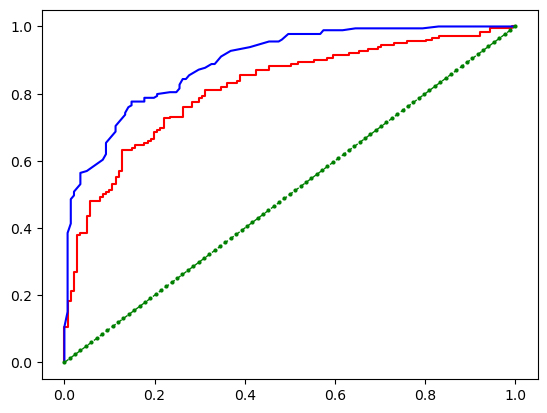

In [140]:
plt.plot(tpr1, fpr1, color = 'red') ## red == Logistic Regression
plt.plot(tpr2, fpr2, color = 'blue') ## blue == Random Forest Classifier
plt.plot(np.linspace(0, 1, 85), np.linspace(0, 1, 85), 'go--', linewidth=1, markersize = 2)
sns.lineplot()

In [141]:
rf_auc = roc_auc_score(y_test, y_prob2)
lor_auc = roc_auc_score(y_test, y_prob1)

In [142]:
1 - rf_auc

0.8933000515075875

In [143]:
1 - lor_auc

0.8155235944371806

HENCE AUC-ROC OF RANDOM_FOREST IS GREATER THAN LOGISTIC REGRESSION ,,, THEREFORE, RANDOM FOREST IS BEST CLASSIFIER HERE IN THIS DATASET

THEN WHAT SHOULD BE THE THRESHOLD IN THIS ... BY BOTH

In [158]:
optimal_index1 = np.argmax(fpr1 - tpr1)
optimal_index2 = np.argmax(fpr2 - tpr2)
print(optimal_index1)
print(optimal_index2)

58
33


In [159]:
print('Threshold for Random Forest Classifier :', threshold2[optimal_index2])
print('Threshold for Logistic Regression Classifier :', threshold1[optimal_index1])

Threshold for Random Forest Classifier : 0.61
Threshold for Logistic Regression Classifier : 0.5362238313951097


In [160]:
## Feature Importance
i = np.argmax(rf.feature_importances_)
j = np.argmax(rf.feature_importances_[:i])
print(i, j)

10 9
